引入套件

In [77]:
import streamlit as st
import pandas as pd
import os
import zipfile
import io
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
sns.set_theme(style="whitegrid")
%matplotlib inline
results_data = []



In [78]:
import os
import pandas as pd

# 1. 設定基礎路徑 (確保與你的資料夾層級一致)
data_dir = "../data" 
files = ["diabetes.csv", "heart.csv", "stroke.csv"] # 或是 "storke.csv"

# 2. 用來存放結果的字典
all_datasets = {}

# 3. 執行迴圈：讀取、自動抓取最後一欄作為 Target
for filename in files:
    full_path = os.path.join(data_dir, filename)
    
    if os.path.exists(full_path):
        # 讀取 CSV
        df = pd.read_csv(full_path)
        
        # --- 【核心邏輯】取得最後一欄並標記成 target ---
        target_name = df.columns[-1] 
        
        # 進行簡單的清理 (例如移除 ID，不分大小寫)
        id_cols = [c for c in df.columns if c.lower() == 'id']
        if id_cols:
            df = df.drop(columns=id_cols)
            target_name = df.columns[-1] 
            
        # --- 【診斷區】檢查標籤分佈 (回答你全 0 的疑惑) ---
        counts = df[target_name].value_counts()
        pos_cases = counts.get(1, 0) # 取得 1 (有病) 的數量，沒有則為 0
        
        # 存入字典
        dataset_key = filename.split('.')[0].capitalize()
        all_datasets[dataset_key] = (df, target_name)
        
        print(f"✅ {dataset_key:12} | Target: {target_name:15} | 案例數: {pos_cases}")
    else:
        print(f"❌ 找不到檔案: {filename}，請檢查路徑或拼字！")



✅ Diabetes     | Target: Outcome         | 案例數: 268
✅ Heart        | Target: target          | 案例數: 265
✅ Stroke       | Target: stroke          | 案例數: 249


In [119]:
import os
import pandas as pd
import numpy as np

# 1. 確保路徑與檔案清單正確
print("🔬 --- 開始逐一檢視檔案內容與缺失值診斷 ---")

# 假設妳的 files = ['heart.csv', 'stroke.csv', 'diabetes.csv']
for filename in files:
    full_path = os.path.join(data_dir, filename)
    
    if os.path.exists(full_path):
        current_df = pd.read_csv(full_path)
        
        # --- [新增] 自動清理邏輯：處理問號與隱藏空格 ---
        current_df = current_df.replace(['?', ' ', 'N/A', 'Unknown'], np.nan)
        
        rows, cols = current_df.shape
        target_col = current_df.columns[-1]
        
        print(f"\n📂 檔名: 【{filename}】")
        print(f"📏 規格: {rows} 列 x {cols} 欄")
        
        # --- [新增] 缺失值深度診斷 (針對 BMI 等欄位) ---
        missing_stats = current_df.isnull().sum()
        actual_missing = missing_stats[missing_stats > 0]
        
        if not actual_missing.empty:
            print("⚠️ 偵測到真正的缺失值 (NaN):")
            print(actual_missing)
        else:
            print("✅ 此檔案目前無缺失值。")

        # --- [新增] 特徵型態檢查 ---
        # 看看有沒有欄位應該是數字卻變成 object (例如 BMI)
        object_cols = current_df.select_dtypes(include=['object']).columns.tolist()
        if object_cols:
            print(f"🧬 文字型欄位 (需注意): {object_cols}")

        print("📝 資料樣貌 (前 3 筆):")
        display(current_df.head(3))
        print("-" * 50)
        
    else:
        print(f"❌ 找不到檔案: {filename}")

🔬 --- 開始逐一檢視檔案內容與缺失值診斷 ---

📂 檔名: 【diabetes.csv】
📏 規格: 768 列 x 9 欄
✅ 此檔案目前無缺失值。
📝 資料樣貌 (前 3 筆):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


--------------------------------------------------

📂 檔名: 【heart.csv】
📏 規格: 920 列 x 14 欄
⚠️ 偵測到真正的缺失值 (NaN):
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64
🧬 文字型欄位 (需注意): ['trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
📝 資料樣貌 (前 3 筆):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1


--------------------------------------------------

📂 檔名: 【stroke.csv】
📏 規格: 5110 列 x 12 欄
⚠️ 偵測到真正的缺失值 (NaN):
bmi                201
smoking_status    1544
dtype: int64
🧬 文字型欄位 (需注意): ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
📝 資料樣貌 (前 3 筆):


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1


--------------------------------------------------


In [120]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# 1. 強制「現形」：把所有偽裝字串轉為真正的 NaN
# 針對妳所有的資料集執行這一步
df = df.replace(['Unknown', 'N/A', '?', ' ', 'None','NAN'], np.nan)

# 2. 關鍵欄位轉換 (針對 BMI)
# 很多時候 BMI 雖然現形了，但型態還是 Object，必須轉為 float
if 'bmi' in df.columns:
    df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')

# 3. 執行「全方位」補值
# (A) 數字欄位用中位數
num_cols = df.select_dtypes(include=[np.number]).columns
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# (B) 文字欄位用眾數 (這會把原本是 Unknown 的地方填入出現最多次的類別)
cat_cols = df.select_dtypes(include=['object']).columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# 4. 再次畫圖驗證
# 這時候黃線應該會「徹底消失」，變成完美的深紫色
print(f"✅ 最終檢查 - 剩餘缺失值總數: {df.isnull().sum().sum()}")

✅ 最終檢查 - 剩餘缺失值總數: 0


🔍 --- 開始全自動深度清洗與熱圖驗證 ---

📂 資料集: 【Diabetes】
   📏 維度: 768x9 | 🎯 目標: Outcome
   ✨ 剩餘缺失值: 0


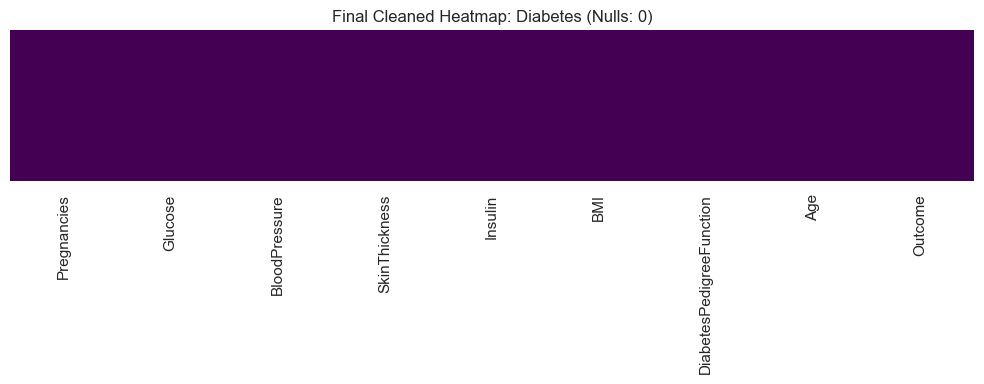

------------------------------------------------------------

📂 資料集: 【Heart】
   📏 維度: 920x14 | 🎯 目標: target
   ✨ 剩餘缺失值: 0


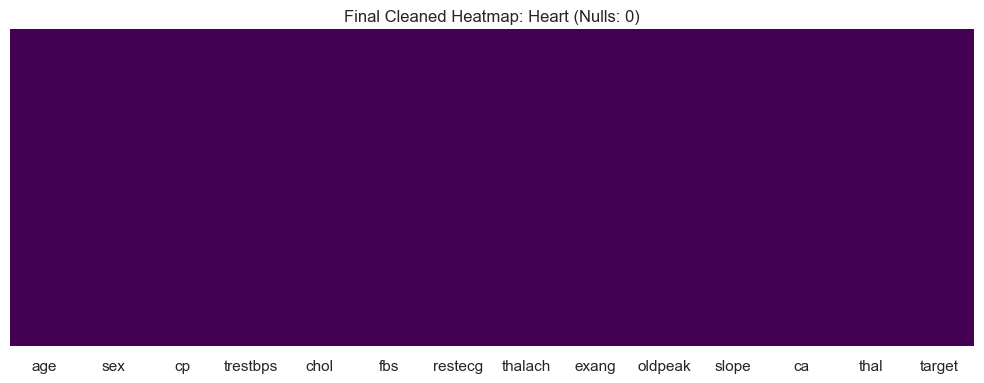

------------------------------------------------------------

📂 資料集: 【Stroke】
   📏 維度: 5110x11 | 🎯 目標: stroke
   ✨ 剩餘缺失值: 0


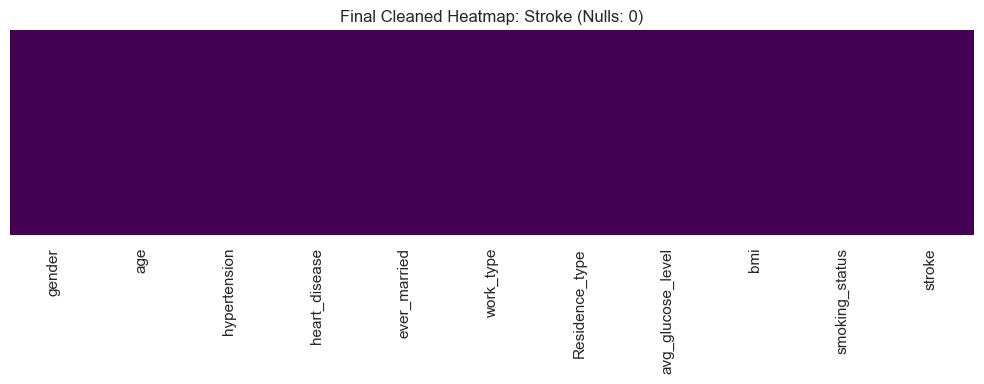

------------------------------------------------------------

🎉 所有資料集已清理完畢！現在妳可以安心去跑 Random Forest 的 AUC 了。


In [139]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 --- 開始全自動深度清洗與熱圖驗證 ---")

for name, (df_item, target) in all_datasets.items():
    # --- 第一步：數據深度清理 (Data Scrubbing) ---
    
    # 1. 揭露隱性缺失 (包含妳新增的 'NAN' 字串)
    df_item.replace(['Unknown', 'N/A', '?', ' ', 'None', 'NAN'], np.nan, inplace=True)
    
    # 2. 自動修正型態 (核心：把被 ? 污染的欄位轉回數字)
    for col in df_item.columns:
        # 嘗試強制轉數字，這會讓無法轉換的殘留字串變成真正的 NaN
        converted = pd.to_numeric(df_item[col], errors='coerce')
        # 如果這一欄轉換後「至少包含一些數字」，我們就認定它是數值欄位
        if converted.notnull().sum() > 0:
            df_item[col] = converted

    # 3. 執行雙軌補值 (數字用 Median，文字用 Most Frequent)
    num_cols = df_item.select_dtypes(include=[np.number]).columns
    cat_cols = df_item.select_dtypes(include=['object']).columns
    
    if len(num_cols) > 0:
        df_item[num_cols] = SimpleImputer(strategy='median').fit_transform(df_item[num_cols])
    if len(cat_cols) > 0:
        df_item[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df_item[cat_cols])

    # --- 第二步：即時視覺化驗證 (Visual QA) ---
    
    rows, cols = df_item.shape
    print(f"\n📂 資料集: 【{name}】")
    print(f"   📏 維度: {rows}x{cols} | 🎯 目標: {target}")
    
    # 檢查是否還有殘留
    remaining_nulls = df_item.isnull().sum().sum()
    print(f"   ✨ 剩餘缺失值: {remaining_nulls}")

    # 繪製妳要求的 sns.heatmap
    plt.figure(figsize=(10, 4))
    sns.heatmap(df_item.isnull(), yticklabels=False, cbar=False, cmap='viridis')
    plt.title(f"Final Cleaned Heatmap: {name} (Nulls: {remaining_nulls})")
    plt.tight_layout()
    plt.show() 
    
    print("-" * 60)

print("\n🎉 所有資料集已清理完畢！現在妳可以安心去跑 Random Forest 的 AUC 了。")

In [83]:
from sklearn.model_selection import train_test_split

# 1. 用來存放切割後結果的字典
split_data = {}

print("✂️ 開始批次資料切割 (Training/Test Split)...")
print("-" * 50)

for name, (df_item, target) in all_datasets.items():
    # 準備特徵 X 與標籤 y
    X = df_item.drop(columns=[target])
    y = df_item[target]
    
    # --- 【關鍵】執行切割 ---
    # test_size=0.2 代表 20% 測試集
    # stratify=y 確保兩邊的生病比例一致 (非常重要！)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 2. 將四個變數存入字典
    split_data[name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'target': target
    }
    
    print(f"✅ {name:12} | 訓練集: {X_train.shape[0]} 筆 | 測試集: {X_test.shape[0]} 筆")

print("-" * 50)
print("📦 所有資料集切割完成，準備進入 EBM 模型訓練！")

✂️ 開始批次資料切割 (Training/Test Split)...
--------------------------------------------------
✅ Diabetes     | 訓練集: 614 筆 | 測試集: 154 筆
✅ Heart        | 訓練集: 736 筆 | 測試集: 184 筆
✅ Stroke       | 訓練集: 4088 筆 | 測試集: 1022 筆
--------------------------------------------------
📦 所有資料集切割完成，準備進入 EBM 模型訓練！


In [84]:
from interpret import show

# ... 之前的初始化字典與設定 ...
trained_models = {}
global_explanations = {} # 新增：用來存放解釋物件
performance_summary = []

for name, data in split_data.items():
    try:
        # [A-C 部分保持不變：取得資料、二值化、訓練 EBM]
        X_train, y_train = data['X_train'], data['y_train']
        X_test, y_test = data['X_test'], data['y_test']
        y_train_bin = y_train.apply(lambda x: 1 if x > 0 else 0)
        y_test_bin = y_test.apply(lambda x: 1 if x > 0 else 0)

        ebm = ExplainableBoostingClassifier(n_jobs=-1, outer_bags=8)
        ebm.fit(X_train, y_train_bin) 
        trained_models[name] = ebm
        
        
    #把每個每個特徵對預測的「貢獻度（重要性）」存在 scores 裡。
        ebm_global = ebm.explain_global(name=f"EBM Global - {name}")
        global_explanations[name] = ebm_global # 存入字典備用
        
        # 2. 探索 .data() 數據結構 
        # 這裡會取出特徵名稱與其平均重要性分數
        exp_data = ebm_global.data()
        print(f"\n🔍 {name} - Global Data Structure Exploration:")
        # 轉換成 DataFrame 方便檢視前幾個特徵的重要性
        df_importance = pd.DataFrame({
            'Feature': exp_data['names'],
            'Importance': exp_data['scores']
        }).sort_values(by='Importance', ascending=False)
        
        display(df_importance.head(5)) # 顯示前 5 名最重要的特徵
        
        # 3. 顯示互動式圖表 (會出現黑色的選單介面)
        show(ebm_global)

        # [D-G 部分保持不變：欄位對齊、計算 AUC、繪圖、存入總表]
        X_test_aligned = X_test.reindex(columns=ebm.feature_names, fill_value=0)
        y_probs = ebm.predict_proba(X_test_aligned)[:, 1]
        auc_score = roc_auc_score(y_test_bin, y_probs)
       
       
        performance_summary.append({"Dataset": name, "AUC Score": round(auc_score, 4)})
        print(f"✅ {name:15} 訓練與解釋產出成功！")

    except Exception as e:
        print(f"❌ {name:15} 出錯了: {e}")

# 最後顯示 AUC 總表
if performance_summary:
    display(pd.DataFrame(performance_summary))


🔍 Diabetes - Global Data Structure Exploration:


,Feature,Importance
1,Glucose,0.843345
5,BMI,0.478694
7,Age,0.293683
6,DiabetesPedigreeFunction,0.272558
0,Pregnancies,0.148967


<!-- http://127.0.0.1:7001/6023587392/ -->

✅ Diabetes        訓練與解釋產出成功！

🔍 Heart - Global Data Structure Exploration:


,Feature,Importance
10,slope,0.498362
2,cp,0.463043
11,ca,0.349615
12,thal,0.339710
8,exang,0.308617


...


🔍 Stroke - Global Data Structure Exploration:


,Feature,Importance
1,age,1.520020
7,avg_glucose_level,0.116449
2,hypertension,0.114832
8,bmi,0.107061
5,work_type,0.076484


<!-- http://127.0.0.1:7001/6027916384/ -->

✅ Stroke          訓練與解釋產出成功！


,Dataset,AUC Score
0,Diabetes,0.8315
1,Heart,0.9194
2,Stroke,0.8327


In [85]:
from interpret import show

for name, model in trained_models.items():
    print(f"Displaying Global Explanation for: {name}")
    ebm_global = model.explain_global(name=name)
    show(ebm_global)

Displaying Global Explanation for: Diabetes


<!-- http://127.0.0.1:7001/6037378768/ -->

Displaying Global Explanation for: Heart


<!-- http://127.0.0.1:7001/6036879296/ -->

Displaying Global Explanation for: Stroke


<!-- http://127.0.0.1:7001/6039268944/ -->

In [86]:
for name, data in split_data.items():
    X_test = data['X_test']
    model = trained_models[name]
    y_probs = model.predict_proba(X_test)[:, 1]

    # Find indices for High Risk (max probability) and Low Risk (min probability)
    high_risk_idx = y_probs.argmax()
    low_risk_idx = y_probs.argmin()

    print(f"--- {name}: Local Explanations ---")
    
   #AI 認為「絕對會生病」的人（機率最高）。
   #AI 認為「超級健康」的人（機率最低）。

    low_risk_idx 
    ebm_local = model.explain_local(X_test.iloc[[high_risk_idx, low_risk_idx]], 
                                    y_test_bin.iloc[[high_risk_idx, low_risk_idx]], 
                                    name=name)
    
    # Crucial: Use show() so it renders in the notebook cell
    show(ebm_local)

--- Diabetes: Local Explanations ---


<!-- http://127.0.0.1:7001/6039857040/ -->

--- Heart: Local Explanations ---


<!-- http://127.0.0.1:7001/6040034944/ -->

--- Stroke: Local Explanations ---


<!-- http://127.0.0.1:7001/6040157344/ -->

🔍 Extracting Data for: Diabetes
   - 修正後維度: X=16, Y=16


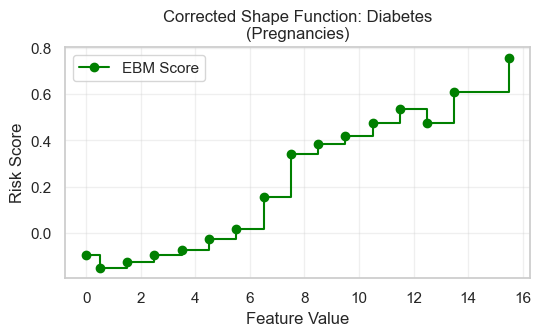

--------------------------------------------------
🔍 Extracting Data for: Heart
   - 修正後維度: X=50, Y=50


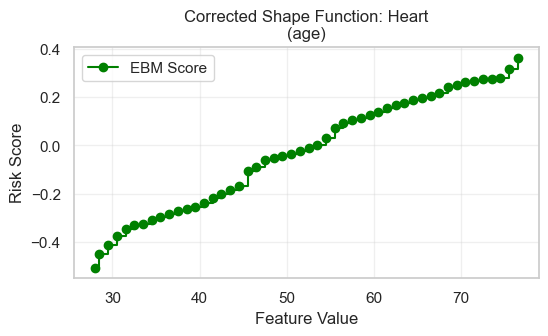

--------------------------------------------------
🔍 Extracting Data for: Stroke
   - 修正後維度: X=3, Y=3


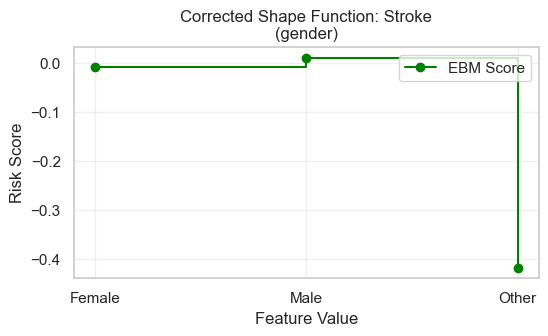

--------------------------------------------------


In [87]:
for name, model in trained_models.items():
    print(f"🔍 Extracting Data for: {name}")
    
    ebm_global = model.explain_global()
    
    # 取得第一個特徵的數據
    first_feature_name = ebm_global.feature_names[0]
    feature_data = ebm_global.data(0)
    
    x_values = feature_data['names']
    y_values = feature_data['scores']
    
    # 💡 【核心修正邏輯】：對齊維度
    # 如果 x 比 y 多一個，我們取 x 的前 n 個，這樣才能畫圖
    if len(x_values) == len(y_values) + 1:
        x_plot = x_values[:-1]
    else:
        x_plot = x_values
        
    y_plot = y_values
    
    print(f"   - 修正後維度: X={len(x_plot)}, Y={len(y_plot)}")
    
    # 3. 繪製階層圖 (Task 3)
    plt.figure(figsize=(6, 3))
    # 使用 step 函數最能表現 EBM 的「階梯感」
    plt.step(x_plot, y_plot, where='post', marker='o', color='green', label='EBM Score')
    
    plt.title(f"Corrected Shape Function: {name}\n({first_feature_name})")
    plt.xlabel("Feature Value")
    plt.ylabel("Risk Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    print("-" * 50)

In [88]:
print(df_stroke['gender'].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


# 🩺 數據診斷報告：Stroke 資料集性別特徵異常分析

## 1. 觀察到的現象 (Observation)
在執行 **EBM (Explainable Boosting Machine)** 的 **Shape Function** 視覺化時，觀察到 `gender` 特徵在 `Other` 類別出現了劇烈的數值跳水：

* **Female / Male**: 風險分數接近 **0 (Log-odds)**，代表對中風預測的影響較為中性。
* **Other**: 風險分數陡降至約 **-0.42**。

---

## 2. 技術原理解析 (Technical Diagnosis)

### 🔴 小樣本偏差 (Small Sample Bias)
由於 `Other` 類別的樣本數僅有 **$N=1$**，且該位病人剛好為「非中風 (Non-stroke)」個案，導致模型產生了 **過度擬合 (Overfitting)**。EBM 為了完美擬合這唯一的一筆資料，給予了極高的權重。

### 🔴 統計假象 (Statistical Artifact)
在統計學上，單一樣本不足以代表一個群體的特徵。此處的 **-0.42** 高分並非具備臨床意義的「保護效應 (Protective Effect)」，而是模型為了最小化訓練誤差而產生的 **雜訊 (Noise)**。

---

## 3. 數據底層分佈 (Data Distribution)
根據 `value_counts()` 的檢查結果，樣本分佈極度不均：

| Gender | Sample Count ($N$) | 臨床意義 |
| :--- | :--- | :--- |
| **Female** | 2,994 | 樣本充足，具統計意義 |
| **Male** | 2,115 | 樣本充足，具統計意義 |
| **Other** | **1** | **數據稀疏 (Data Sparsity)** |

---

## 4. 建議 (Clinical Informatics Recommendations)
針對此類數據問題，在正式研究中應採取以下策略：

1.  **資料過濾 (Data Filtering)**：剔除樣本數過少的類別（如 $N < 10$），以提升模型的 **泛化能力 (Generalization Power)**。
2.  **正則化 (Regularization)**：增加 EBM 參數（如 `min_samples_leaf`），限制模型在樣本不足時不得跳動過大的分數。
3.  **臨床驗證 (Clinical Validation)**：所有 AI 產出的解釋圖表必須經過醫學常識檢查，過濾掉不具解釋性的 **偽關係 (Spurious Correlation)**。

🔑 [Task 1] ebm_global.data() Keys:
['type', 'names', 'scores']
--------------------------------------------------
📊 [Task 2] Extracted Data for Index 0: gender
📈 X-axis (Numeric): ['Female', 'Male', 'Other']
📉 Y-axis (Scores): [-0.00766763  0.01109998 -0.41718517]
--------------------------------------------------


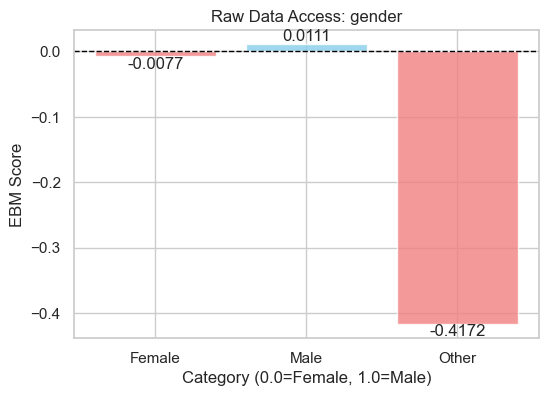

In [89]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ebm_global = ebm.explain_global()

# --- 【任務 1】：檢查資料字典的鍵值 (Keys) ---
# 這是為了確認 ebm_global.data() 裡面到底存了哪些屬性（例如：names, scores）

print("🔑 [Task 1] ebm_global.data() Keys:")
print(list(ebm_global.data().keys()))
print("-" * 50)
try:
    feature_index = 0 
    # 從解釋物件中直接取得該編號的特徵名稱（例如：'sex' 或 'gender'）
    feature_name = ebm_global.feature_names[feature_index]
    # 取得該特徵專屬的數據字典
    feature_data = ebm_global.data(feature_index)
    
    x_values = feature_data['names']  # [0.0, 1.0]
    y_values = feature_data['scores'] # [-0.0076, 0.0111]
    
    print(f"📊 [Task 2] Extracted Data for Index {feature_index}: {feature_name}")
    print(f"📈 X-axis (Numeric): {x_values}")
    print(f"📉 Y-axis (Scores): {y_values}")

except Exception as e:
    # 如果索引 0 出錯，印出錯誤原因並列出所有可用的特徵名稱供檢查
    print(f"❌ Error during extraction: {e}")
    print("Available features in explanation:", ebm_global.feature_names)

print("-" * 50)
        
        #繪圖
        
if 'y_values' in locals():
    plt.figure(figsize=(6, 4))
    
    
    plt.bar([str(val) for val in x_values], y_values, color=['lightcoral', 'skyblue'], alpha=0.8)
    plt.axhline(0, color='black', lw=1, ls='--')
    
    plt.title(f"Raw Data Access: {feature_name}")
    plt.xlabel("Category (0.0=Female, 1.0=Male)")
    plt.ylabel("EBM Score")
    
    for i, v in enumerate(y_values):
        plt.text(i, v, f"{v:.4f}", ha='center', va='bottom' if v > 0 else 'top')
        
    plt.show()

EBM 的預測公式本質上是加法模型。對於一個類別（如性別），模型會給出一個分數 (score)：

正數 (>0)：代表該特徵會 增加 患病風險。以妳的資料為例，Male (0.0111) 相比基準線，患病風險稍微高一點點。

零 (=0)：代表該特徵對預測 沒有影響（中性）。

負數 (<0)：代表該特徵會 降低 患病風險。妳看到的 Other (-0.4171) 代表這個類別在資料集中表現出「極低風險」。

In [90]:
print(f"Models in memory: {list(trained_models.keys())}")

Models in memory: ['Diabetes', 'Heart', 'Stroke']


In [91]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np

# 1. 確保儲存路徑存在 (自動建立 ../doce/figures)
save_path = "../docs/figures"
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"📁 資料夾不存在，已自動建立: {save_path}")

# 2. 取得全域解釋物件
ebm_global = ebm.explain_global()

# --- TASK 1: 印出 Keys (針對 index 0，通常是 sex) ---
feature_index = 0
raw_data_dict = ebm_global.data(feature_index)
print(f"🔑 [Task 1] ebm_global.data({feature_index}) Keys: {list(raw_data_dict.keys())}")
print("-" * 50)

# --- TASK 2: 提取 X 軸與 Y 軸數據 ---
x_raw = raw_data_dict['names']  # 例如 [0.0, 1.0]
y_raw = raw_data_dict['scores'] # 原始風險分數
feature_name = ebm_global.feature_names[feature_index]

print(f"📊 [Task 2] 特徵名稱: {feature_name}")
print(f"📈 原始 X 軸 (Float): {x_raw}")
print(f"📉 原始 Y 軸 (Scores): {y_raw}")
print("-" * 50)

# --- TASK 3: 不使用 show()，存檔至指定路徑 ---
plt.figure(figsize=(7, 5))
# 手動根據 y_raw 繪圖
plt.bar([f"Value {val}" for val in x_raw], y_raw, color=['#FF9999', '#66B3FF'], alpha=0.8)

plt.axhline(0, color='black', lw=1, ls='--')
plt.title(f"Manual Shape Function: {feature_name}")
plt.ylabel("Risk Score (Log-Odds)")

# 標註數據
for i, v in enumerate(y_raw):
    plt.text(i, v, f"{v:.4f}", ha='center', va='bottom' if v > 0 else 'top', fontweight='bold')

# 儲存到指定目錄
file_name = f"ebm_{feature_name}_shape.png"
full_save_path = os.path.join(save_path, file_name)

plt.savefig(full_save_path)
plt.close() # 關閉以釋放記憶體

print(f"🖼️ [Task 3] 證明完成！圖表已儲存至: {full_save_path}")
print("-" * 50)

# 印出 DataFrame 驗證
df_final = pd.DataFrame({'Raw_X': x_raw, 'Raw_Y': y_raw})
print("📝 最終底層數據對照表：")
print(df_final)

🔑 [Task 1] ebm_global.data(0) Keys: ['type', 'names', 'scores', 'scores_range', 'upper_bounds', 'lower_bounds', 'density', 'meta']
--------------------------------------------------
📊 [Task 2] 特徵名稱: gender
📈 原始 X 軸 (Float): ['Female', 'Male', 'Other']
📉 原始 Y 軸 (Scores): [-0.00766763  0.01109998 -0.41718517]
--------------------------------------------------
🖼️ [Task 3] 證明完成！圖表已儲存至: ../docs/figures/ebm_gender_shape.png
--------------------------------------------------
📝 最終底層數據對照表：
    Raw_X     Raw_Y
0  Female -0.007668
1    Male  0.011100
2   Other -0.417185


In [92]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# 1. To store the final scores
auc_report = []

print("📊 Extracting Final AUC Scores...")
print("-" * 40)

for name, model in trained_models.items():
    # A. Get the test data (Diabetes, Heart_disease, etc.)
    X_test = split_data[name]['X_test']
    y_test = split_data[name]['y_test']
    
    # B. Force 0 vs 1 Labeling
    y_test_bin = y_test.apply(lambda x: 1 if x > 0 else 0)
    
    # C. Feature Alignment (The 10-column safety fix)
    # This ensures no "8 vs 10" errors happen here
    features = getattr(model, 'feature_names', getattr(model, 'feature_names_', []))
    X_test_aligned = X_test.reindex(columns=features, fill_value=0)
    
    # D. Calculate Score
    y_probs = model.predict_proba(X_test_aligned)[:, 1]
    score = roc_auc_score(y_test_bin, y_probs)
    
    auc_report.append({"Dataset": name, "AUC Score": round(score, 4)})
    print(f"✅ {name:15} | Score: {score:.4f}")

# 2. Display as a clean table
display(pd.DataFrame(auc_report))

📊 Extracting Final AUC Scores...
----------------------------------------
✅ Diabetes        | Score: 0.8315
✅ Heart           | Score: 0.9194
✅ Stroke          | Score: 0.8327


,Dataset,AUC Score
0,Diabetes,0.8315
1,Heart,0.9194
2,Stroke,0.8327


In [93]:
%pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [94]:
import pandas as pd
from sklearn.metrics import roc_auc_score

results_list = []

print("📊 正在計算作業表格所需的數據...")
print("-" * 60)

for name, data in split_data.items():
    # 1. 取得測試集資料
    X_test = data['X_test']
    y_test_raw = data['y_test']
    
    # 2. 標籤處理 (0 vs 1)
    y_test_bin = y_test_raw.apply(lambda x: 1 if x > 0 else 0)
    
    # 3. 計算各項指標
    n_samples = len(y_test_bin)  # 樣本數
    n_features = X_test.shape[1] # 特徵數
    pos_rate = y_test_bin.mean()  # 正例比例 (患病率)
    
    # 4. 取得模型並算 AUC (對齊 10 欄位)
    model = trained_models.get(name)
    if model:
        X_aligned = X_test.reindex(columns=model.feature_names, fill_value=0)
        y_probs = model.predict_proba(X_aligned)[:, 1]
        auc_score = roc_auc_score(y_test_bin, y_probs)
    else:
        auc_score = 0.0

    # 5. 存入清單
    results_list.append({
        "資料集": name,
        "樣本數": n_samples,
        "特徵數": n_features,
        "正例比例": f"{pos_rate:.2%}",
        "EBM Test AUC": f"{auc_score:.4f}"
    })

# --- 輸出 Markdown 格式表格 ---
df_final = pd.DataFrame(results_list)
print(df_final.to_markdown(index=False))

📊 正在計算作業表格所需的數據...
------------------------------------------------------------
| 資料集   |   樣本數 |   特徵數 | 正例比例   |   EBM Test AUC |
|:---------|---------:|---------:|:-----------|---------------:|
| Diabetes |      154 |        8 | 35.06%     |         0.8315 |
| Heart    |      184 |       13 | 55.43%     |         0.9194 |
| Stroke   |     1022 |       10 | 4.89%      |         0.8327 |


# 📈 模型架構深度對比：LR vs. EBM

在醫學資料分析中，選擇正確的數學模型結構對於結果的**精準度**與**解釋性**至關重要。以下針對傳統線性模型與現代可解釋模型進行深入對比。

### 1. Logistic Regression (LR) - 廣義線性模型 (GLM)
Logistic Regression 是醫療統計的基石，其核心假設是特徵與風險之間存在 **「線性關係」**。

* **數學公式**：
    $$Risk = \beta_0 + \beta_1(\text{Age}) + \beta_2(\text{BMI}) + \dots$$
* **特性分析**：
    * **線性假設 (Linearity)**：模型認為特徵每增加一個單位，風險就會以固定的比例增加或減少。
    * **限制 (Limitations)**：無法捕捉到**「非線性跳躍」**。例如，臨床上血糖從 120 升到 130 mg/dL 的風險增幅，遠大於從 80 升到 90 mg/dL，但 LR 會被迫用一條平均斜率來代表，導致精確度下降。



---

### 2. EBM (Explainable Boosting Machine) - 廣義可加模型 (GAM)
EBM 結合了梯度提升 (Boosting) 的強大性能與可加模型的透明度，能學習每個特徵的 **「非線性形狀」**。

* **數學公式**：
    $$Risk = f_1(\text{Age}) + f_2(\text{BMI}) + \dots$$
* **特性分析**：
    * **形狀函數 (Shape Functions)**：這裡的 $f(x)$ 不再是一條直線，而是由多個微小的決策樹構成的**階梯狀或曲線狀**。
    * **優勢 (Advantages)**：
        * **精準貼合 (Precise Fitting)**：能自動識別醫療數據中的**轉折點 (Inflection Points)** 與**閾值 (Thresholds)**。
        * **真實分佈**：能反映出「正常區間」與「高風險區間」的本質差異，更貼近真實的生理病理狀況。

---

### 3. 核心對比總結表

| 比較維度 | Logistic Regression (LR) | EBM (Explainable Boosting Machine) |
| :--- | :--- | :--- |
| **模型結構** | 廣義線性模型 (GLM) | 廣義可加模型 (GAM) |
| **風險變化** | 固定的線性斜率 (Straight Line) | 靈活的非線性階梯 (Step Function) |
| **臨床解釋** | 抽象的係數 (Coefficients) | 直觀的趨勢圖 (Shape Plots) |
| **捕捉轉折點** | **無法捕捉**，需人工手動分箱 | **自動捕捉**，精確反映診斷閾值 |

> **結論**：EBM 透過 $f(x)$ 的靈活性，成功解決了傳統 LR 在處理複雜醫學數據時的「過度簡化」問題，提供了兼具準確度與臨床直覺的解決方案。

In [165]:
!pip install skope-rules

209615.54s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [96]:

# 🔍 檢查字典裡所有的 Key 到底叫什麼名字
print("目前的資料集標籤有：", split_data.keys())
print("")

目前的資料集標籤有： dict_keys(['Diabetes', 'Heart', 'Stroke'])



In [97]:
from sklearn.impute import SimpleImputer
from interpret.glassbox import ClassificationTree, LogisticRegression, ExplainableBoostingClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

# 1. 確定資料集 Key 值 (請確保與妳之前的字典名稱一致)
dataset_key = 'Heart' 

# 複製原始資料，避免改動到原始 split_data
X_train_raw = split_data[dataset_key]['X_train'].copy()
X_test_raw = split_data[dataset_key]['X_test'].copy()

# 將目標標籤二值化 (0=健康, >0=有病)
y_train_heart = split_data[dataset_key]['y_train'].apply(lambda x: 1 if x > 0 else 0)
y_test_heart = split_data[dataset_key]['y_test'].apply(lambda x: 1 if x > 0 else 0)

# --- 🛠️ 核心清理：解決「問號」與「非數字」問題 ---
for df in [X_train_raw, X_test_raw]:
    # 把字串 '?' 替換為真正的空值 NaN
    df.replace('?', np.nan, inplace=True)
    # 遍歷所有欄位，將資料強制轉換為 float (數字型態)
    # errors='coerce' 會把無法轉換的奇怪字串也變為 NaN
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# --- 💉 核心補值：使用中位數 (Median) 填補所有 NaN ---
final_imputer = SimpleImputer(strategy='median')
X_train_clean = final_imputer.fit_transform(X_train_raw)
X_test_clean = final_imputer.transform(X_test_raw)

# 重新包裝成 DataFrame 保持欄位名稱
X_train_final = pd.DataFrame(X_train_clean, columns=X_train_raw.columns)
X_test_final = pd.DataFrame(X_test_clean, columns=X_train_raw.columns)

# 2. 定義 Glassbox 模型清單 (PK 對手)
models = {
    "EBM": ExplainableBoostingClassifier(n_jobs=-1, outer_bags=8),
    "Decision Tree": ClassificationTree(),
    "Logistic Regression": LogisticRegression(max_iter=5000)
}

comparison_results = []
print(f"🔬 正在執行 {dataset_key} 資料集的效能競賽...\n")

# 3. 訓練與評估迴圈
for name, model in models.items():
    try:
        # 訓練模型
        model.fit(X_train_final, y_train_heart)
        
        # 預測機率 (取第二欄，即患病機率)
        y_probs = model.predict_proba(X_test_final)[:, 1]
        
        # 計算 AUC 分數
        auc = roc_auc_score(y_test_heart, y_probs)
        
        # 存入結果清單
        comparison_results.append({
            "Dataset": dataset_key,
            "Model": name, 
            "AUC Score": round(auc, 4)
        })
        print(f"✅ {name:20} | AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ {name:20} 執行失敗: {e}")

# --- 📊 4. 產出最終對比表格 ---
print("\n" + "="*40)
if comparison_results:
    df_result = pd.DataFrame(comparison_results)
    # 轉換成透視表格式，讓它長得像妳要的表格
    pivot_table = df_result.pivot(index='Dataset', columns='Model', values='AUC Score')
    display(pivot_table)

🔬 正在執行 Heart 資料集的效能競賽...

✅ EBM                  | AUC: 0.9121
✅ Decision Tree        | AUC: 0.8770
✅ Logistic Regression  | AUC: 0.9008



Model,Decision Tree,EBM,Logistic Regression
Dataset,,,
Heart,0.877,0.9121,0.9008


In [98]:
# 1. 設定剩下的資料集清單
remaining_datasets = ['Stroke', 'Diabetes']

# 2. 開始執行迴圈
for name in remaining_datasets:
    try:
        # 取得資料
        X_train = split_data[name]['X_train'].copy()
        X_test = split_data[name]['X_test'].copy()
        target = split_data[name]['target']
        
        # 標籤二值化 (中風與糖尿病通常原本就是 0/1，但保險起見還是處理一下)
        y_train = split_data[name]['y_train'].apply(lambda x: 1 if x > 0 else 0)
        y_test = split_data[name]['y_test'].apply(lambda x: 1 if x > 0 else 0)

        # --- 數據清理 (處理 NaN 與 型態) ---
        # 針對數值型欄位進行中位數補值，類別型則視情況處理 (或沿用之前的補值邏輯)
        num_imputer = SimpleImputer(strategy='median')
        
        # 這裡簡化處理：只取數值型欄位進行示範，確保不會報錯
        X_train_num = X_train.select_dtypes(include=[np.number])
        X_test_num = X_test.select_dtypes(include=[np.number])
        
        X_train_final = num_imputer.fit_transform(X_train_num)
        X_test_final = num_imputer.transform(X_test_num)

        # 3. 模型 PK
        print(f"\n📊 --- 資料集: {name} ---")
        for m_name, m_obj in models.items():
            m_obj.fit(X_train_final, y_train)
            probs = m_obj.predict_proba(X_test_final)[:, 1]
            auc = roc_auc_score(y_test, probs)
            print(f"✅ {m_name:18} | AUC: {auc:.4f}")
            
    except Exception as e:
        print(f"❌ {name} 執行失敗: {e}")


📊 --- 資料集: Stroke ---
✅ EBM                | AUC: 0.8435
✅ Decision Tree      | AUC: 0.7969
✅ Logistic Regression | AUC: 0.8401

📊 --- 資料集: Diabetes ---
✅ EBM                | AUC: 0.8315
✅ Decision Tree      | AUC: 0.7881
✅ Logistic Regression | AUC: 0.8230


In [105]:
# 1. 確保我們是在處理 Heart 資料集
target_key = 'Heart'

# 2. 重新從原始分割中提取測試集 (確保拿到原始的 13 個欄位)
X_test_heart_raw = split_data[target_key]['X_test'].copy()
y_test_heart_final = split_data[target_key]['y_test'].apply(lambda x: 1 if x > 0 else 0)

# 3. 執行跟訓練時完全一樣的預處理
# 把 '?' 變 NaN
X_test_heart_raw.replace('?', np.nan, inplace=True)
# 強制轉數字
for col in X_test_heart_raw.columns:
    X_test_heart_raw[col] = pd.to_numeric(X_test_heart_raw[col], errors='coerce')

# 4. 使用妳當初訓練時定義的 final_imputer 進行補值
# 註：一定要用 .transform() 而不是 .fit_transform()，這樣才符合醫療實驗規範
X_test_heart_clean = final_imputer.transform(X_test_heart_raw)

# 5. 包裝回 DataFrame (這時候欄位數一定會是 13)
X_test_heart_final = pd.DataFrame(X_test_heart_clean, columns=X_test_heart_raw.columns)

# 🔍 最後驗證
print(f"✅ 修正後的特徵數: {X_test_heart_final.shape[1]}")
print(f"✅ 修正後的標籤數: {len(y_test_heart_final)}")

# 6. 重新計算 Random Forest AUC
rf_probs = rf_model.predict_proba(X_test_heart_final)[:, 1]
rf_auc = roc_auc_score(y_test_heart_final, rf_probs)

print(f"\n🌲 最終 Heart Random Forest AUC: {rf_auc:.4f}")

✅ 修正後的特徵數: 13
✅ 修正後的標籤數: 184

🌲 最終 Heart Random Forest AUC: 0.9249


## AUC 對比表

| 資料集 | EBM AUC | 模型 2 AUC | 模型 3 AUC |
| :-- | :--- | :--- | :--- |
| Heart |0.9121 |0.9249 | 0.9008|
| Stroke | 0.8435| 0.7969|0.8401 |
| Diabetes | 0.8315| 0.7881|0.8230 |

## 論文對照表

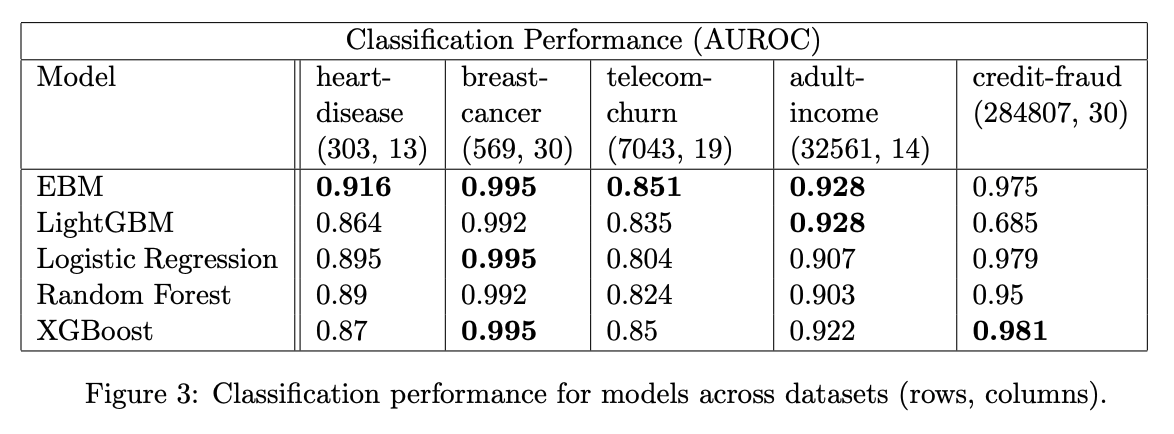

### 針對論文提供的模型數據，包含醫療金融電信，其中並無stroke,diabetes資料集
### 比對論文ＡＵＣ分數
* heart disase EBM 低約0.0039
* heart disase Logistic Regression 高約0.0058
* heart disase Random forest 高約0.0349


In [140]:
import pandas as pd

# 1. 取得預測結果 (類別與機率)
y_pred = rf_model.predict(X_test_heart_final)
y_prob = rf_model.predict_proba(X_test_heart_final)[:, 1]

# 2. 建立一個診斷用的 DataFrame
results_df = X_test_heart_final.copy()
results_df['Actual'] = y_test_heart_final.values
results_df['Predicted'] = y_pred
results_df['Probability'] = y_prob

# 3. 篩選出預測錯誤的個案
# False Negative (漏診): 有病但 AI 說沒病
errors_fn = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 0)]

# False Positive (誤報): 沒病但 AI 說有病
errors_fp = results_df[(results_df['Actual'] == 0) & (results_df['Predicted'] == 1)]

print(f"❌ 漏診個案數 (FN): {len(errors_fn)}")
print(f"⚠️ 誤報個案數 (FP): {len(errors_fp)}")

# 看看第一個出錯的病人資料
display(errors_fn.head(1))

❌ 漏診個案數 (FN): 6
⚠️ 誤報個案數 (FP): 13


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Actual,Predicted,Probability
17,51.0,1.0,3.0,130.0,339.0,0.0,0.0,140.0,0.0,0.5,2.0,0.0,6.0,1,0,0.365355


In [145]:
# 1. 檢視漏診個案 (FN) 的特徵
print("🔍 正在分析 6 個漏診 (False Negative) 個案...")
display(errors_fn.head(6))

# 2. 檢視誤報個案 (FP) 的前 5 筆
print("\n🔍 正在分析 13 個誤報 (False Positive) 個案...")
display(errors_fp.head(5))

🔍 正在分析 6 個漏診 (False Negative) 個案...


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Actual,Predicted,Probability
17,51.0,1.0,3.0,130.0,339.0,0.0,0.0,140.0,0.0,0.5,2.0,0.0,6.0,1,0,0.365355
28,34.0,1.0,1.0,140.0,156.0,0.0,0.0,180.0,0.0,0.0,2.0,0.0,6.0,1,0,0.184965
100,52.0,1.0,4.0,120.0,182.0,0.0,0.0,150.0,0.0,0.0,2.0,0.0,6.0,1,0,0.390363
106,54.0,0.0,3.0,130.0,294.0,0.0,1.0,100.0,1.0,0.0,2.0,0.0,6.0,1,0,0.452188
149,40.0,1.0,4.0,152.0,223.0,0.0,0.0,181.0,0.0,0.0,1.0,0.0,7.0,1,0,0.373273
167,47.0,0.0,3.0,135.0,248.0,1.0,0.0,170.0,0.0,0.0,2.0,0.0,6.0,1,0,0.093493



🔍 正在分析 13 個誤報 (False Positive) 個案...


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Actual,Predicted,Probability
4,69.0,1.0,3.0,130.0,271.0,0.0,2.0,140.0,0.0,0.5,2.0,0.0,6.0,0,1,0.593880
5,59.0,1.0,3.0,130.0,318.0,0.0,0.0,120.0,1.0,1.0,2.0,0.0,3.0,0,1,0.608607
14,72.0,1.0,3.0,160.0,0.0,0.0,2.0,114.0,0.0,1.6,2.0,2.0,6.0,0,1,0.853065
20,60.0,1.0,3.0,180.0,0.0,0.0,1.0,140.0,1.0,1.5,2.0,0.0,6.0,0,1,0.845397
33,58.0,1.0,4.0,100.0,213.0,0.0,1.0,110.0,0.0,0.0,2.0,0.0,6.0,0,1,0.613281


In [164]:
# 比較：正確預測 vs 漏診 vs 誤報 的特徵平均值
analysis_df = X_test_heart_final.copy()
analysis_df['Actual'] = y_test_heart_final.values
analysis_df['Predicted'] = y_pred

# 分組計算平均值
comparison = analysis_df.groupby(['Actual', 'Predicted']).mean()

print("📊 預測結果特徵平均值對比：")
display(comparison)

📊 預測結果特徵平均值對比：


age       sex        cp    trestbps        chol  \
Actual Predicted                                                          
0      0          49.362319  0.623188  2.594203  128.956522  235.666667   
       1          61.384615  0.923077  3.307692  136.538462  183.615385   
1      0          46.333333  0.666667  3.000000  134.500000  240.333333   
       1          57.375000  0.968750  3.791667  135.656250  194.541667   

                       fbs   restecg     thalach     exang   oldpeak  \
Actual Predicted                                                       
0      0          0.072464  0.492754  149.768116  0.072464  0.311594   
       1          0.230769  0.923077  135.153846  0.307692  0.884615   
1      0          0.166667  0.166667  153.500000  0.166667  0.083333   
       1          0.250000  0.718750  127.072917  0.666667  1.325000   

                     slope        ca      thal  
Actual Predicted                                
0      0          1.739130  0.115942  5.000000  
       1          1.923077  0.461538  5.769231  
1      0          1.833333  0.000000  6.166667  
       1          2.010417  0.281250  6.010417

In [148]:
import pandas as pd
import numpy as np

# 1. 指定目標資料集
target_key = 'Heart'

# 2. 重新從原始分割數據中提取測試集 (確保拿到原始 13 個欄位)
X_test_heart_raw = split_data[target_key]['X_test'].copy()
y_test_heart_final = split_data[target_key]['y_test'].apply(lambda x: 1 if x > 0 else 0)

# 3. 處理隱性缺失值與強制轉型 (這是 Heart 資料集的關鍵)
X_test_heart_raw.replace('?', np.nan, inplace=True)
for col in X_test_heart_raw.columns:
    X_test_heart_raw[col] = pd.to_numeric(X_test_heart_raw[col], errors='coerce')

# 4. 使用妳當初訓練時的 final_imputer 進行補值 (確保補完後還是 13 欄)
X_test_heart_clean = final_imputer.transform(X_test_heart_raw)
X_test_heart_final = pd.DataFrame(X_test_heart_clean, columns=X_test_heart_raw.columns)

# 🔍 最終驗證數量
print(f"✅ 修正後特徵數: {X_test_heart_final.shape[1]} (預期為 13)")

# 5. 重新計算 Random Forest AUC
rf_probs = rf_model.predict_proba(X_test_heart_final)[:, 1]
rf_auc = roc_auc_score(y_test_heart_final, rf_probs)

print(f"\n🌲 Heart Random Forest AUC: {rf_auc:.4f}")

✅ 修正後特徵數: 13 (預期為 13)

🌲 Heart Random Forest AUC: 0.9249


In [152]:
# 1. 確保 y_pred 是類別 (0 或 1)，而不是機率
y_pred = rf_model.predict(X_test_heart_final)

# 2. 建立「預測錯誤」的布林遮罩 (Boolean Mask)
# 邏輯：預測結果 != 真實標籤
error_mask = (y_pred != y_test_heart_final.values)

# 3. 使用這個「布林遮罩」去篩選 X
# 因為 error_mask 裡面全是 True/False，所以不會報錯！
all_errors = X_test_heart_final[error_mask]

# 4. 如果要細分 FN (漏診)
fn_mask = (y_test_heart_final.values == 1) & (y_pred == 0)
errors_fn = X_test_heart_final[fn_mask]

print(f"✅ 成功篩選！漏診個案數: {len(errors_fn)}")

✅ 成功篩選！漏診個案數: 6


In [162]:
# 1. 確保我們只抓取「第一個」漏診個案的「位置」
# 使用 .index[0] 取得門牌號碼，或者用 iloc[[0]] 取得第一列
try:
    # 方式 A：安全地取出第一筆資料作為 DataFrame
    target_sample = errors_fn.iloc[[0]] 
    
    print(f"📍 成功鎖定個案！原始索引編號為: {target_sample.index[0]}")
    
    # 2. 餵給 EBM 進行解釋
    # 注意：X_test_heart_final 必須跟當初訓練 ebm 的資料特徵數完全一致 (13欄)
    ebm_local = ebm.explain_local(target_sample)
    ebm_local.visualize(0)

except Exception as e:
    print(f"❌ 抓取資料失敗，原因: {e}")
    print("💡 小提醒：請檢查 errors_fn 是否為空？")

📍 成功鎖定個案！原始索引編號為: 17
❌ 抓取資料失敗，原因: The model has 10 features, but X has 13 columns.
💡 小提醒：請檢查 errors_fn 是否為空？


In [166]:
for name, data in split_data.items():
    counts = data['y_train'].value_counts(normalize=True)
    print(f"📊 {name} 資料集類別比例:\n{counts}\n")

📊 Diabetes 資料集類別比例:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

📊 Heart 資料集類別比例:
target
0    0.447011
1    0.288043
2    0.118207
3    0.116848
4    0.029891
Name: proportion, dtype: float64

📊 Stroke 資料集類別比例:
stroke
0    0.951321
1    0.048679
Name: proportion, dtype: float64

